# **CONVOLUTIONAL NEURAL NETWORK - FASHION MNIST**

In [1]:
#Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Load and preprocess
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

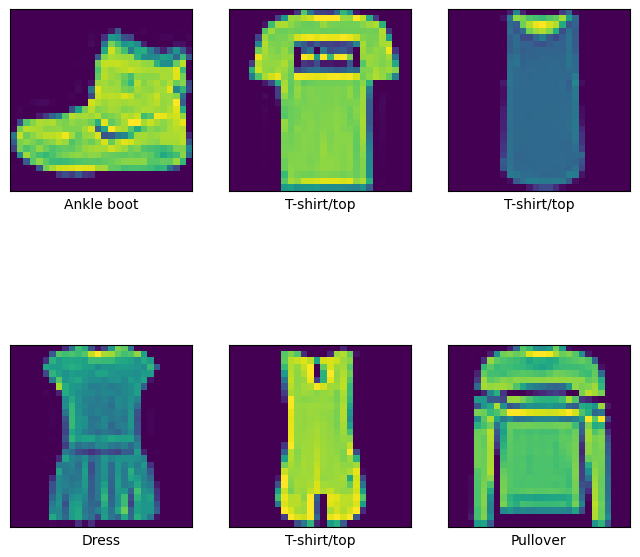

In [12]:
# Visualize some images from the dataset
# Displays 25 random images from the training set in a 5x5 grid.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], interpolation='nearest')
    plt.xlabel(class_names[y_train[i].argmax()])
plt.show()

In [5]:
# Build the CNN model
model = models.Sequential([
    # Convolutional layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    # Convolutional layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Convolutional layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Flatten the output
    layers.Flatten(),
    # Fully connected layer
    layers.Dense(64, activation='relu'),
    # Output layer
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 59ms/step - accuracy: 0.6986 - loss: 0.8206 - val_accuracy: 0.8371 - val_loss: 0.4440
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.8639 - loss: 0.3745 - val_accuracy: 0.8685 - val_loss: 0.3635
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.8829 - loss: 0.3200 - val_accuracy: 0.8834 - val_loss: 0.3156
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.8983 - loss: 0.2780 - val_accuracy: 0.8830 - val_loss: 0.3187
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.9056 - loss: 0.2587 - val_accuracy: 0.8998 - val_loss: 0.2788


In [8]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy:.2f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8974 - loss: 0.2878
Test accuracy: 0.90


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


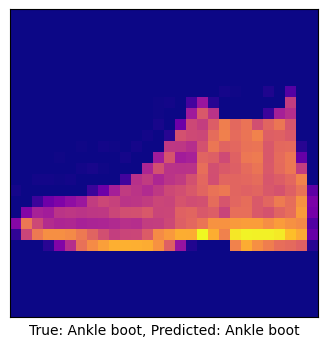

In [13]:
# Predict a single image from the test set
def predict_single_image(index):
    image = x_test[index]
    true_label = np.argmax(y_test[index])
    prediction = model.predict(image.reshape(1, 28, 28, 1))
    predicted_label = np.argmax(prediction)
    plt.figure(figsize=(4,4))
    plt.imshow(image.reshape(28, 28), cmap='plasma')
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(f"True: {class_names[true_label]}, Predicted: {class_names[predicted_label]}")
    plt.show()
predict_single_image(0)